In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [99]:
DATA_ROOT = './data'

In [ ]:
#logTPM_res = pd.read_csv(f'{DATA_ROOT}/MSE_results_logTPM.csv', index_col = 0)
TPM_res = pd.read_csv(f'{DATA_ROOT}/MSE_results_TPM_FIXED.csv', index_col = 0, header = 0)
external_res = pd.read_csv(f'{DATA_ROOT}/external_MSE_TPM.csv', index_col= 0, header = 0)

In [102]:
merged_results = pd.read_csv(f'{DATA_ROOT}/merged_results.csv', index_col= 0, header = 0)

In [ ]:
#merged_results = TPM_res
#merged_results['external_res'] = external_res['external_set_score']
#merged_results.to_csv(f'{DATA_ROOT}/merged_results.csv')

In [23]:
TPM_res.loc[TPM_res['train_score'] > 0.5, :].shape[0]

872

In [27]:
#log_to_plot = pd.melt(logTPM_res)
TPM_to_plot = pd.melt(TPM_res)

In [25]:
#create function make train test MSE violin plot
def loss_violin_plot(df, palette, title, figtitle):
    fig, ax = plt.subplots()
    ax = sns.violinplot(data = df, x = 'variable', y="value", hue = 'variable', palette=palette)
    ax.set_ylabel('MSE', fontsize = 15)
    ax.set_xlabel('Dataset', fontsize = 15)
    fig.canvas.draw()
    labels = [item.get_text() for item in ax.get_xticklabels()]
    labels[0], labels[1] = ['Training', 'Test']
    ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
    fig.suptitle(title, fontsize = 20)
    plt.savefig(figtitle, dpi = 300)

/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_64904/1421562481.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Training', 'Test'], fontsize = 10)


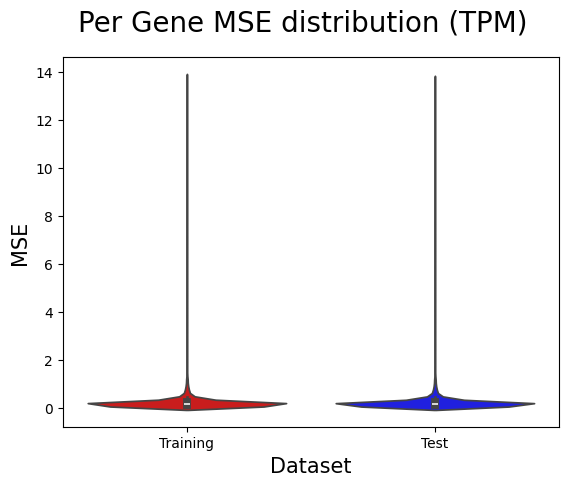

In [13]:
loss_violin_plot(TPM_to_plot, palette=['#e60000', '#0000ff'], title ='Per Gene MSE distribution (TPM)', figtitle= 'figures/TPM_train_test')

# External dataset erorr scores

In [107]:
#get absolute differneces between TPM and external results
merged_results['TPM_ext_diff'] = abs(merged_results['test_score'] - merged_results['external_res'])

In [127]:
merged_results

,train_score,test_score,external_res,in_features,TPM_ext_diff,log_diff
A2M,1.311736,1.303155,139.467880,13,138.164725,4.944979
A2ML1,1.273549,1.279204,0.396865,1,0.882340,0.334230
A3GALT2,0.020525,0.022068,0.005650,49,0.016418,0.005634
A4GALT,0.148902,0.147038,0.307168,80,0.160129,0.267863
AAAS,0.194445,0.190268,2.473180,121,2.282911,1.245071
...,...,...,...,...,...,...
ZYG11A,0.132777,0.131225,0.213470,67,0.082244,0.193484
ZYG11B,0.088438,0.090258,0.359522,58,0.269264,0.307133
ZYX,0.398363,0.392438,8.669482,133,8.277044,2.268975
ZZEF1,0.141486,0.142128,0.116785,97,0.025344,0.110454


In [ ]:
merged_results.loc[merged_results['TPM_ext_diff'] > 0.5].shape

(5313, 5)

In [153]:
import math
merged_results['log_diff'] = np.log(merged_results['external_res'] + 1)

Text(0.5, 1.0, 'Distribution of model sizes')

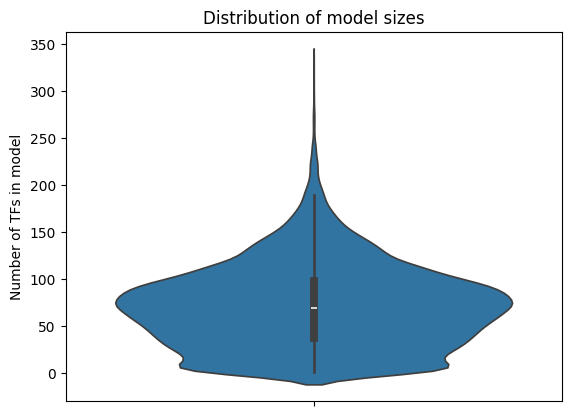

In [122]:
sns.violinplot(merged_results['in_features'])
plt.ylabel('Number of TFs in model')
plt.title('Distribution of model sizes')

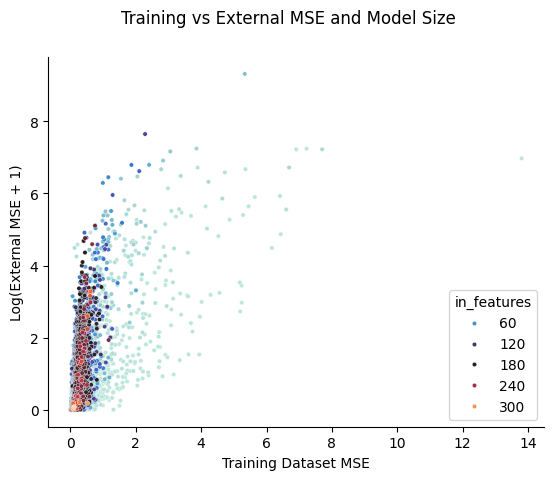

In [ ]:
fig, ax = plt.subplots(ncols=1)

sorted_results = merged_results.sort_values('in_features')
sns.scatterplot(data=sorted_results, x = 'train_score', y = 'log_diff', legend=True, ax = ax, hue = 'in_features', palette='icefire', s=10)
sns.despine()
ax.set_xlabel('Training Dataset MSE', fontsize = 10)
ax.set_ylabel('Log(External MSE + 1)', fontsize = 10)
fig.suptitle('Training vs External MSE and Model Size')
plt.savefig('figures/trainVSdiff')

In [163]:
np.exp(0.5)-1

np.float64(0.6487212707001282)

In [160]:
merged_results.loc[merged_results['log_diff'] < 0.2]

,train_score,test_score,external_res,in_features,TPM_ext_diff,log_diff
A3GALT2,0.020525,0.022068,0.005650,49,0.016418,0.005634
AANAT,0.067428,0.067504,0.077257,96,0.009754,0.074418
AARD,0.114731,0.123526,0.009282,13,0.114245,0.009239
ABCA10,0.232641,0.213896,0.124894,8,0.089002,0.117689
ABCA12,0.054104,0.058045,0.008026,22,0.050019,0.007994
...,...,...,...,...,...,...
ZXDA,0.082946,0.082325,0.022920,60,0.059405,0.022662
ZXDB,0.133503,0.129292,0.107076,62,0.022216,0.101722
ZYG11A,0.132777,0.131225,0.213470,67,0.082244,0.193484
ZZEF1,0.141486,0.142128,0.116785,97,0.025344,0.110454


/var/folders/31/nm2_1xn55zl20tj7l_p3rzb40000gn/T/ipykernel_64904/2617786981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = merged_results, y="external_res", palette=['#e60000'])


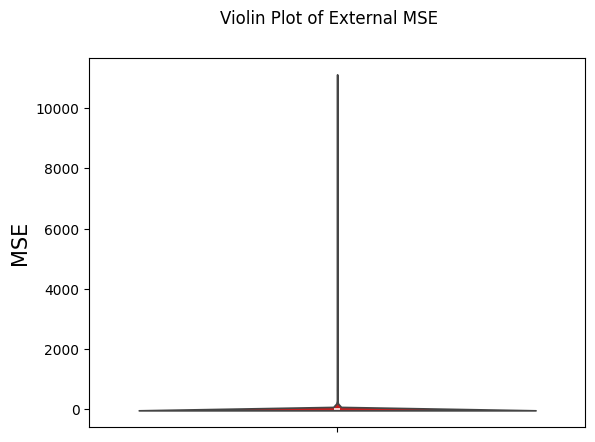

In [167]:
fig, ax = plt.subplots()
ax = sns.violinplot(data = merged_results, y="external_res", palette=['#e60000'])
ax.set_ylabel('MSE', fontsize = 15)
fig.suptitle('Violin Plot of External MSE')
plt.show()
#ax.set_xlabel('Dataset', fontsize = 15)
#fig.canvas.draw()
#labels = [item.get_text() for item in ax.get_xticklabels()]
#labels[0], labels[1] = ['Training', 'Test']
#ax.set_xticklabels(['Training', 'Test'], fontsize = 10)
#fig.suptitle(title, fontsize = 20)
#plt.savefig(figtitle, dpi = 300)